In [1]:
import yaml, torch, sys, json, random, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from types import SimpleNamespace
from PIL import Image, ImageFont, ImageDraw
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF
sys.path.insert(0, '../../')
# import random
from utils.train_model import run_experiment, set_seed, get_device
from collections import defaultdict






In [2]:
def to_namespace(d):
    if isinstance(d, dict):
        return SimpleNamespace(**{k: to_namespace(v) for k, v in d.items()})
    return d

with open('../../configs/defaults.yaml') as f:
    config = yaml.safe_load(f)

with open('../../configs/EX_03_04.yaml') as f:
    config.update(yaml.safe_load(f))

config = to_namespace(config)
set_seed(config.seed)
device = get_device()
RAW_DIR  = Path(config.raw_dir)
GRAD_DIR = Path(config.grad_dir)
data_dir = Path('./EX_03_04/Raw/')

[device] using cuda


# Context
......

We're going to finalize the glyph set for the project. So we're adding fashion mnist, adding back mnist proper. keeping fonts too but killing:
Vertical-stroke family: I, l, 1 all collapse to the same blob. Plus J.
Oval family: O, 0, plus C/Q/D when blurred (the tail on Q and the bar on D vanish). Drop O, 0, C, Q.U/V collapse together post-blur. 
dropping S, Z, B, G) bc similar to digits

# Code


In [3]:
def box_blur(x, kernel_size=9):
    channels = x.shape[1]
    kernel = torch.ones(channels, 1, kernel_size, kernel_size, 
                        device=x.device) / (kernel_size ** 2)
    return F.conv2d(x, kernel, padding=kernel_size//2, groups=channels)

def bandwtn(image):
    # image shape: (B, C, H, W)
    if image.shape[1] == 3:
        gray = (
            0.299 * image[:, 0:1] +
            0.587 * image[:, 1:2] +
            0.114 * image[:, 2:3]
        )
        # repeat to 3 channels to match input
        return gray.repeat(1, 3, 1, 1)
    
    elif image.shape[1] == 1:
        # already grayscale, just return
        return image
    
    else:
        raise ValueError(f"Unsupported number of channels: {image.shape[1]}")

def alpha_combine(b, i):
    alpha = i.expand_as(b)
    comp = alpha * i.expand_as(b) + (1 - alpha) * b
    return comp
    
def additive_combine(b, i):
    """
    b: (B, 3, H, W) background
    i: (B, 1, H, W) or (B, 3, H, W) digit
    returns: (B, 3, H, W) composite, clamped
    """
    return (b + i.expand_as(b)).clamp(0, 1)

# All glyphs loading

In [4]:
DIGITS    = list("0123456789")                       # 10 — keep all
UPPERCASE = list("AEFHKLMNPRTVWXY")                   # 15 — dropped B(8) C(O) D(O) G(6) I(1) J(I) O(0) Q(O) S(5) U(V) Z(2)
LOWERCASE = list("adefhnrt")                          # 8  — EMNIST-distinct minus b(8) g(9) q(9)
FMNIST    = ["tshirt","trouser","pullover","dress","coat",
             "sandal","shirt","sneaker","bag","ankleboot"]  # 10
SYMBOLS   = list("★♥●▲■◆✚▼◀▶⬟⬢")                    # 12

CLASSES = (
    [("digit",  c) for c in DIGITS]    +
    [("upper",  c) for c in UPPERCASE] +
    [("lower",  c) for c in LOWERCASE] +
    [("fmnist", i) for i in range(len(FMNIST))] +
    [("symbol", c) for c in SYMBOLS]
)
NUM_CLASSES = len(CLASSES)  # 55

# Each class draws from one or more sources, picked uniformly per sample.
# Lowercase font renders are skipped — at 28px they're too small relative
# to uppercase, which gives them an unfair handicap in the diagnostic.
SOURCES_FOR_KIND = {
    "digit":  ["mnist", "font_inter", "font_serif"],
    "upper":  ["emnist", "font_inter", "font_serif"],
    "lower":  ["emnist"],
    "fmnist": ["fmnist"],
    "symbol": ["font_symbols"],
}

# EMNIST balanced label → char mapping (47 classes)
EMNIST_BALANCED_CHARS = (
    list("0123456789") +
    list("ABCDEFGHIJKLMNOPQRSTUVWXYZ") +
    list("abdefghnqrt")
)

FONT_PATHS = {
    "inter":   "../../shared_models/assets/Helvetica-Bold.ttf",
    "serif":   "../../shared_models/assets/AppleGaramond-Bold.ttf",
    "symbols": "../../shared_models/assets/NotoSansSymbols2-Regular.ttf",
}

def _idx_by_label(targets, label_to_key):
    idx = {k: [] for k in label_to_key.values()}
    arr = targets.numpy() if torch.is_tensor(targets) else targets
    for i, lbl in enumerate(arr):
        key = label_to_key.get(int(lbl))
        if key is not None:
            idx[key].append(i)
    return idx

def _render_font_glyph(char, font, size):
    img  = Image.new("L", (size, size), 0)
    draw = ImageDraw.Draw(img)
    bbox = draw.textbbox((0, 0), char, font=font)
    x = (size - (bbox[2] - bbox[0])) // 2 - bbox[0]
    y = (size - (bbox[3] - bbox[1])) // 2 - bbox[1]
    draw.text((x, y), char, fill=255, font=font)
    return TF.to_tensor(img)  # (1, size, size)

def _emnist_fix(pil_img):
    # EMNIST is stored transposed; this is the canonical un-transpose.
    return pil_img.transpose(Image.TRANSPOSE)

def glyph_bgrnd(size, bg_type):
    if bg_type == "blank":
        return torch.zeros(3, size, size)
    raise ValueError(f"unknown bg_type: {bg_type}")

class UnifiedGlyphDataset(Dataset):
    def __init__(self, num_samples=60000, size=28, bg_type="blank"):
        self.num_samples = num_samples
        self.size = size
        self.bg_type = bg_type

        # Raw datasets (no transform — we handle PIL → tensor by hand)
        self.mnist  = datasets.MNIST(root="./data", train=True, download=True)
        self.emnist = datasets.EMNIST(root="./data", split="balanced",
                                       train=True, download=True)
        self.fmnist = datasets.FashionMNIST(root="./data", train=True, download=True)

        # Per-class index lookups (built once via .targets, fast)
        self.mnist_idx  = _idx_by_label(
            self.mnist.targets,
            {i: str(i) for i in range(10)},
        )
        emnist_label_to_char = {
            i: c for i, c in enumerate(EMNIST_BALANCED_CHARS)
            if c in set(UPPERCASE + LOWERCASE)
        }
        self.emnist_idx = _idx_by_label(self.emnist.targets, emnist_label_to_char)
        self.fmnist_idx = _idx_by_label(
            self.fmnist.targets,
            {i: i for i in range(10)},
        )

        # Fonts — sized per source so glyphs fit the 28px box even when bold
        self.fonts = {
            "inter":   ImageFont.truetype(FONT_PATHS["inter"],   size=int(size * 0.95)),
            "serif":   ImageFont.truetype(FONT_PATHS["serif"],   size=int(size * 0.95)),
            "symbols": ImageFont.truetype(FONT_PATHS["symbols"], size=int(size * 0.80)),
        }

    def __len__(self):
        return self.num_samples

    def _get_glyph(self, kind, key):
        source = random.choice(SOURCES_FOR_KIND[kind])

        if source == "mnist":
            i = random.choice(self.mnist_idx[key])
            pil, _ = self.mnist[i]
            return TF.to_tensor(pil)
        if source == "emnist":
            i = random.choice(self.emnist_idx[key])
            pil, _ = self.emnist[i]
            return TF.to_tensor(_emnist_fix(pil))
        if source == "fmnist":
            i = random.choice(self.fmnist_idx[key])
            pil, _ = self.fmnist[i]
            return TF.to_tensor(pil)
        if source == "font_inter":
            return _render_font_glyph(key, self.fonts["inter"], self.size)
        if source == "font_serif":
            return _render_font_glyph(key, self.fonts["serif"], self.size)
        if source == "font_symbols":
            return _render_font_glyph(key, self.fonts["symbols"], self.size)
        raise ValueError(f"unknown source: {source}")

    def __getitem__(self, idx):
        label = random.randrange(NUM_CLASSES)
        kind, key = CLASSES[label]
        glyph = self._get_glyph(kind, key)

        background   = glyph_bgrnd(self.size, self.bg_type)
        comp         = torch.cat([background, glyph], dim=0)
        target_color = torch.rand(3)
        return comp, label, target_color


# ============================================================
# n = 100
n = 60000
ex03_04_trainset = UnifiedGlyphDataset(num_samples=n)
train_size = int(0.9 * n)
val_size   = n - train_size
train_set, val_set = random_split(
    ex03_04_trainset, [train_size, val_size],
    generator=torch.Generator().manual_seed(config.seed)
)
ex03_04_trainloader = DataLoader(train_set, batch_size=config.batch_size, shuffle=True)
ex03_04_valloader   = DataLoader(val_set,   batch_size=config.batch_size)

In [5]:
len(ex03_04_trainloader)

NameError: name 'ds' is not defined

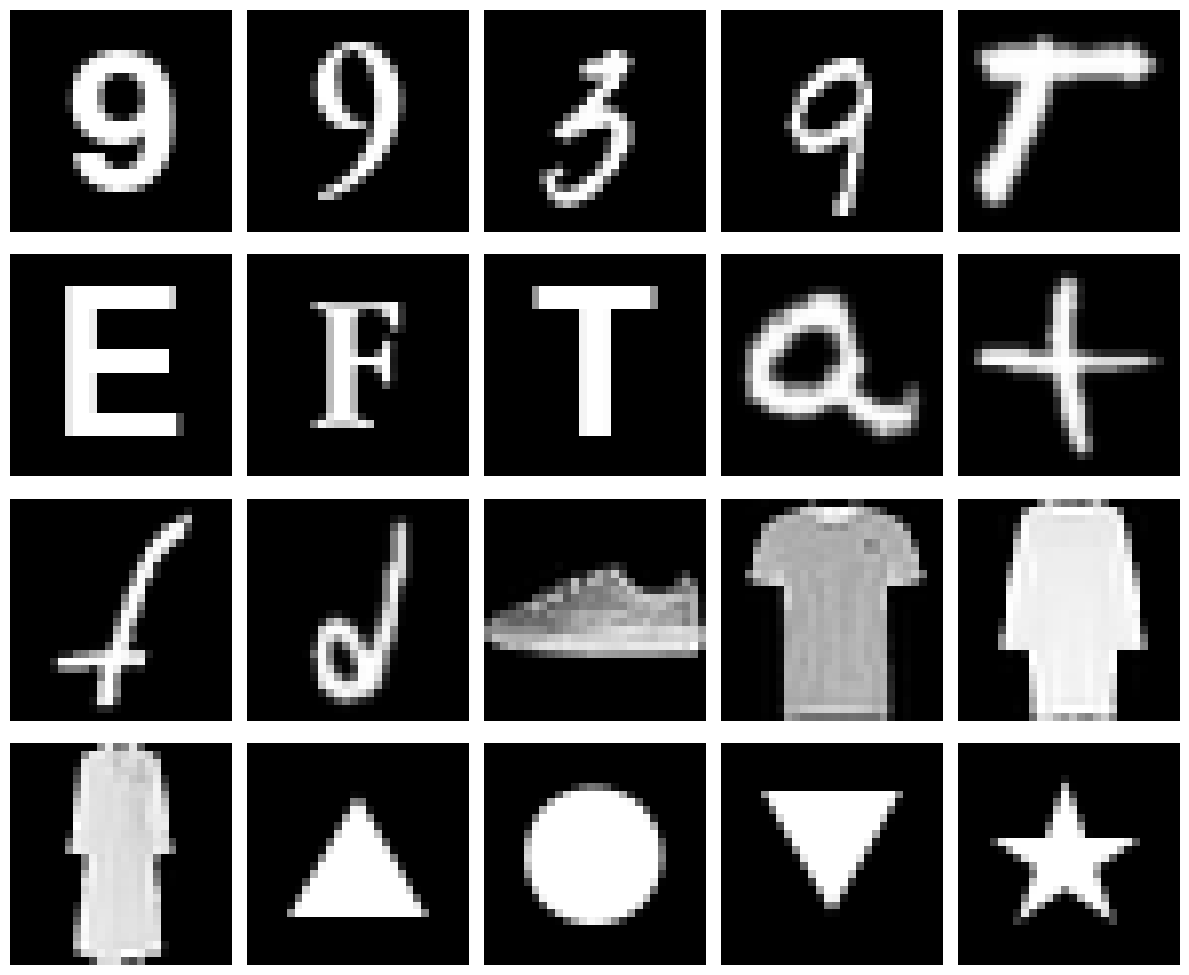

In [9]:
ds = UnifiedGlyphDataset(num_samples=100)

def label_to_str(label):
    kind, key = CLASSES[label]
    if kind == "fmnist":
        return FMNIST[key]
    return key

# fig, axes = plt.subplots(2, 8, figsize=(16, 4))
# for ax in axes.flat:
#     comp, label, tc = ds[random.randint(0, len(ds)-1)]
#     glyph = comp[3].numpy()  # (28, 28), values in [0, 1]

#     # Composite: target color background, white glyph on top
#     bg  = tc.numpy().reshape(1, 1, 3)              # (1, 1, 3)
#     rgb = np.broadcast_to(bg, (28, 28, 3)).copy()  # tinted background
#     a   = glyph[..., None]                         # (28, 28, 1) alpha
#     rgb = rgb * (1 - a) + np.array([1, 1, 1]) * a  # white glyph

#     ax.imshow(rgb)
#     ax.set_title(label_to_str(label), fontsize=9)
#     ax.axis("off")
# plt.tight_layout()
# plt.show()
from collections import defaultdict

TARGET_PER_KIND = 4
KINDS = ["digit", "upper", "lower", "fmnist", "symbol"]

kind_to_samples = defaultdict(list)

max_attempts = 5000
for _ in range(max_attempts):
    if all(len(kind_to_samples[k]) >= TARGET_PER_KIND for k in KINDS):
        break
    idx = random.randint(0, len(ds) - 1)
    comp, label, tc = ds[idx]
    kind = CLASSES[label][0]
    if len(kind_to_samples[kind]) < TARGET_PER_KIND:
        kind_to_samples[kind].append((comp, label, tc))

samples = []
for k in KINDS:
    samples.extend(kind_to_samples[k])

fig, axes = plt.subplots(4, 5, figsize=(12, 10))

for ax, (comp, label, tc) in zip(axes.flat, samples):
    glyph = comp[3].numpy()
    rgb = np.zeros((28, 28, 3))                          # black background
    a   = glyph[..., None]
    rgb = rgb * (1 - a) + np.array([1, 1, 1]) * a       # white glyph
    ax.imshow(rgb)
    ax.axis("off")


plt.tight_layout()
plt.show()
fig.savefig("dataset_samples.png", dpi=150, bbox_inches="tight")

# Simple Classifier for all Glpyhs

In [6]:
#mnist classifier and data loading
#this remains a 3 channel classifier, as in both pre- and post-, we sum the image before classification
class LeNet3channel_allGlyphs(nn.Module):
    def __init__(self, num_classes=55):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 5, padding=2)   
        self.conv2 = nn.Conv2d(16, 32, 5)
        self.fc1   = nn.Linear(32*5*5, 240)
        self.fc2   = nn.Linear(240, 168)
        self.fc3   = nn.Linear(168, num_classes)
        self.dropout = nn.Dropout(0.2)
    def forward(self, x):
        x = F.avg_pool2d(F.relu(self.conv1(x)), 2)
        x = F.avg_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        return self.fc3(x)


def ex_03_04a_loss_fn(batch, model, epoch, total_epochs, mode="train", **kwargs):
    comp, labels, _ = batch
    b, i  = comp[:, :3], comp[:, 3:]
    logits = model(i)
    loss = nn.CrossEntropyLoss()(logits, labels)

    if mode == "val":
        acc = (logits.argmax(1) == labels).float().mean().item()
        return {"val_loss": loss.item(), "val_acc": acc}
    return loss


# ── RUN ───────────────────────────────────────────────────────────────────────
ex_03_04a_info = {
    "exp_id":      "EX_03_04a",
    "epochs":      config.variants.a.epochs,
    "log_to":      "both", #"file" if you dont want wandb 
    "weights_dir": "Model/A",
    "log_dir":     "logs/A",
    "seed":        42,
    "notes": config.variants.a.description
}

In [7]:


if True: #change to retrain
    ex_03_04a_model = LeNet3channel_allGlyphs().to(device)
    ex_03_04a_model.load_state_dict(torch.load('Model/A/EX_03_04a_final.pt', map_location=device, weights_only=True))
    ex_03_04a_model.eval()

else:
    ex_03_04a_model = LeNet3channel_allGlyphs()
    optimizer = torch.optim.Adam(ex_03_04a_model.parameters(), lr=config.variants.a.lr)
    run_experiment(
        model=ex_03_04a_model,
        optimizer=optimizer,
        loss_fn=ex_03_04a_loss_fn,
        train_loader=ex03_04_trainloader,
        val_loader=ex03_04_valloader,
        config=ex_03_04a_info,
        log_to=ex_03_04a_info["log_to"],
    )
    

In [40]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def evaluate_classifier(model, loader, num_classes, device="cuda"):
    model.eval().to(device)
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            comp, labels, _ = batch
            comp, labels = comp.to(device), labels.to(device)
            imgs = comp[:, 3:4]
            logits = model(imgs)
            preds  = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()

    overall_acc = (preds == labels).mean()
    print(f"Overall accuracy: {overall_acc:.4f}\n")

    # Per-class accuracy — this is what you actually care about for the diagnostic
    print(f"{'class':<12} {'acc':>6} {'n':>5}")
    print("-" * 26)
    per_class = []
    for c in range(num_classes):
        mask = labels == c
        n = mask.sum()
        acc = (preds[mask] == c).mean() if n > 0 else float("nan")
        kind, key = CLASSES[c]
        name = FMNIST[key] if kind == "fmnist" else str(key)
        per_class.append((c, name, acc, n))
        print(f"{name:<12} {acc:>6.3f} {n:>5}")

    cm = confusion_matrix(labels, preds, labels=list(range(num_classes)))
    # top confusion pairs
    for i in range(num_classes):
        for j in range(num_classes):
            if i != j and cm[i, j] > 5:  # threshold for "notable"
                ni = FMNIST[CLASSES[i][1]] if CLASSES[i][0] == "fmnist" else CLASSES[i][1]
                nj = FMNIST[CLASSES[j][1]] if CLASSES[j][0] == "fmnist" else CLASSES[j][1]
                print(f"{ni} -> {nj}: {cm[i,j]}")

    # Sorted bottom-10 — the cull candidates
    print("\nWorst 10 classes:")
    for c, name, acc, n in sorted(per_class, key=lambda x: x[2])[:10]:
        print(f"  {name:<12} {acc:.3f}  (n={n})")

    return per_class

per_class = evaluate_classifier(ex_03_04a_model, ex03_04_valloader, NUM_CLASSES)



Overall accuracy: 0.9020

class           acc     n
--------------------------
0             1.000   107
1             1.000   114
2             0.949    98
3             0.931   130
4             0.950   119
5             0.950   119
6             0.964   112
7             0.983   117
8             0.907   107
9             0.909   121
A             0.885   113
E             0.927   110
F             0.783   120
H             0.926   108
K             0.882    93
L             0.893   103
M             0.957   115
N             0.878   115
P             0.922   102
R             0.861   115
T             0.956   113
V             0.950    80
W             0.956   113
X             0.906   127
Y             0.924   105
a             0.889    99
d             0.940   100
e             0.920   112
f             0.769   121
h             0.867   113
n             0.881   109
r             0.901   101
t             0.904   114
tshirt        0.793    92
trouser       0.906   128
pullover   

In [11]:

# returns conf, predicted
def m_classify_3d_with_conf(image, correct):
    if image.shape[1] != 3:
        raise Exception(f"expected a 3 dim image, got a image of shape {image.shape}")
    # with torch.no_grad():
    logits = ex_03_04a_model(image)
    preds = torch.softmax(logits, dim=1)
    max_pred = torch.argmax(logits, dim=1)
    return preds[torch.arange(preds.shape[0]), correct], max_pred

# EX_01_04 Generator for all Glyphs.

In [12]:

class singleBlock0cBlurredGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(NUM_CLASSES + 2, 128),
            nn.ReLU(),
            nn.Linear(128, 7*7*32),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),  # 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 4, stride=2, padding=1),   # 28x28
            nn.Sigmoid()
        )
    
    def forward(self, label_onehot):
        return self.net(label_onehot)
        

def ex_03_04b_loss_fn(batch, model, mode="train", **kwargs):
    # b, i, label, b_idx, i_idx = batch
    comp, label, _ = batch
    b, i = comp[:, :3], comp[:, 3:]
    noise   = torch.randn(label.shape[0], 2).to(device)
    onehot  = F.one_hot(label, num_classes=NUM_CLASSES).float()
    x       = torch.cat([onehot, noise], dim=1)
    generated = model(x)
    generated_1d = generated.mean(dim=1, keepdim=True) 
    # conf_pre, pred_pre  = m_classify_3d_with_conf(generated, label) #we're doing the articulated model, should'n't need this i think
    logits   = ex_03_04a_model(generated_1d)
    probs    = F.softmax(logits, dim=1)
    
    conf_pre = probs[torch.arange(probs.shape[0]), label]
    pred_pre = logits.argmax(dim=1)

    blurred_real = box_blur(i, kernel_size=3) #no-op
    blurred_gen  = box_blur(generated_1d)

    post_loss    = F.mse_loss(blurred_gen, blurred_real)

    delta_vis = (config.variants.c.alpha * conf_pre) + (config.variants.c.beta * post_loss)
    delta_vis = (-delta_vis).mean() if delta_vis.dim() > 0 else -delta_vis
    loss = delta_vis 
    if mode == "val":
        return {
            "val_loss":  loss.item(),
            "conf_pre":  conf_pre.mean().item(),
            "post_loss": post_loss.item(),
            "delta_vis": delta_vis.mean().item()
        }
    return loss


# ── RUN ───────────────────────────────────────────────────────────────────────
EX_03_04b_info = {
    "exp_id":      "EX_03_04b",
    "epochs":      config.variants.b.epochs,
    "log_to":      "both", #"file" if you dont want wandb 
    "weights_dir": "Model/B",
    "log_dir":     "logs/B",
    "seed":        42,
    "notes": config.variants.b.description
}

ex_03_04b_model = singleBlock0cBlurredGenerator()
optimizer = torch.optim.Adam(ex_03_04b_model.parameters(), lr=config.lr)


In [13]:
run_experiment(
    model=ex_03_04b_model,
    optimizer=optimizer,
    loss_fn=ex_03_04b_loss_fn,
    train_loader=ex03_04_trainloader,
    val_loader=ex03_04_valloader,
    config=EX_03_04b_info,
    log_to=EX_03_04b_info["log_to"],
)

# ex_03_04b_model = singleBlock0cBlurredGenerator().to(device)
# ex_03_04b_model.load_state_dict(torch.load('Model/B/ex_03_04b_final.pt', map_location=device, weights_only=True))
# ex_03_04b_model.eval()

[device] using cuda


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /ihome/xli/sek188/.netrc.
wandb: Currently logged in as: sek188 (teamMaverick) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


conf_pre,█▄▄▂▃▂▂▃▁▂
delta_vis,█▃▂▂▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
post_loss,█▃▂▂▁▁▁▁▁▁
train_loss,█▃▂▁▁▁▁▁▁▁
val_loss,█▃▂▂▁▁▁▁▁▁
conf_pre,0.00041
delta_vis,0.01756
epoch,10
post_loss,0.03851
train_loss,0.01742


singleBlock0cBlurredGenerator(
  (net): Sequential(
    (0): Linear(in_features=57, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1568, bias=True)
    (3): ReLU()
    (4): Unflatten(dim=1, unflattened_size=(32, 7, 7))
    (5): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): ReLU()
    (7): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (8): Sigmoid()
  )
)

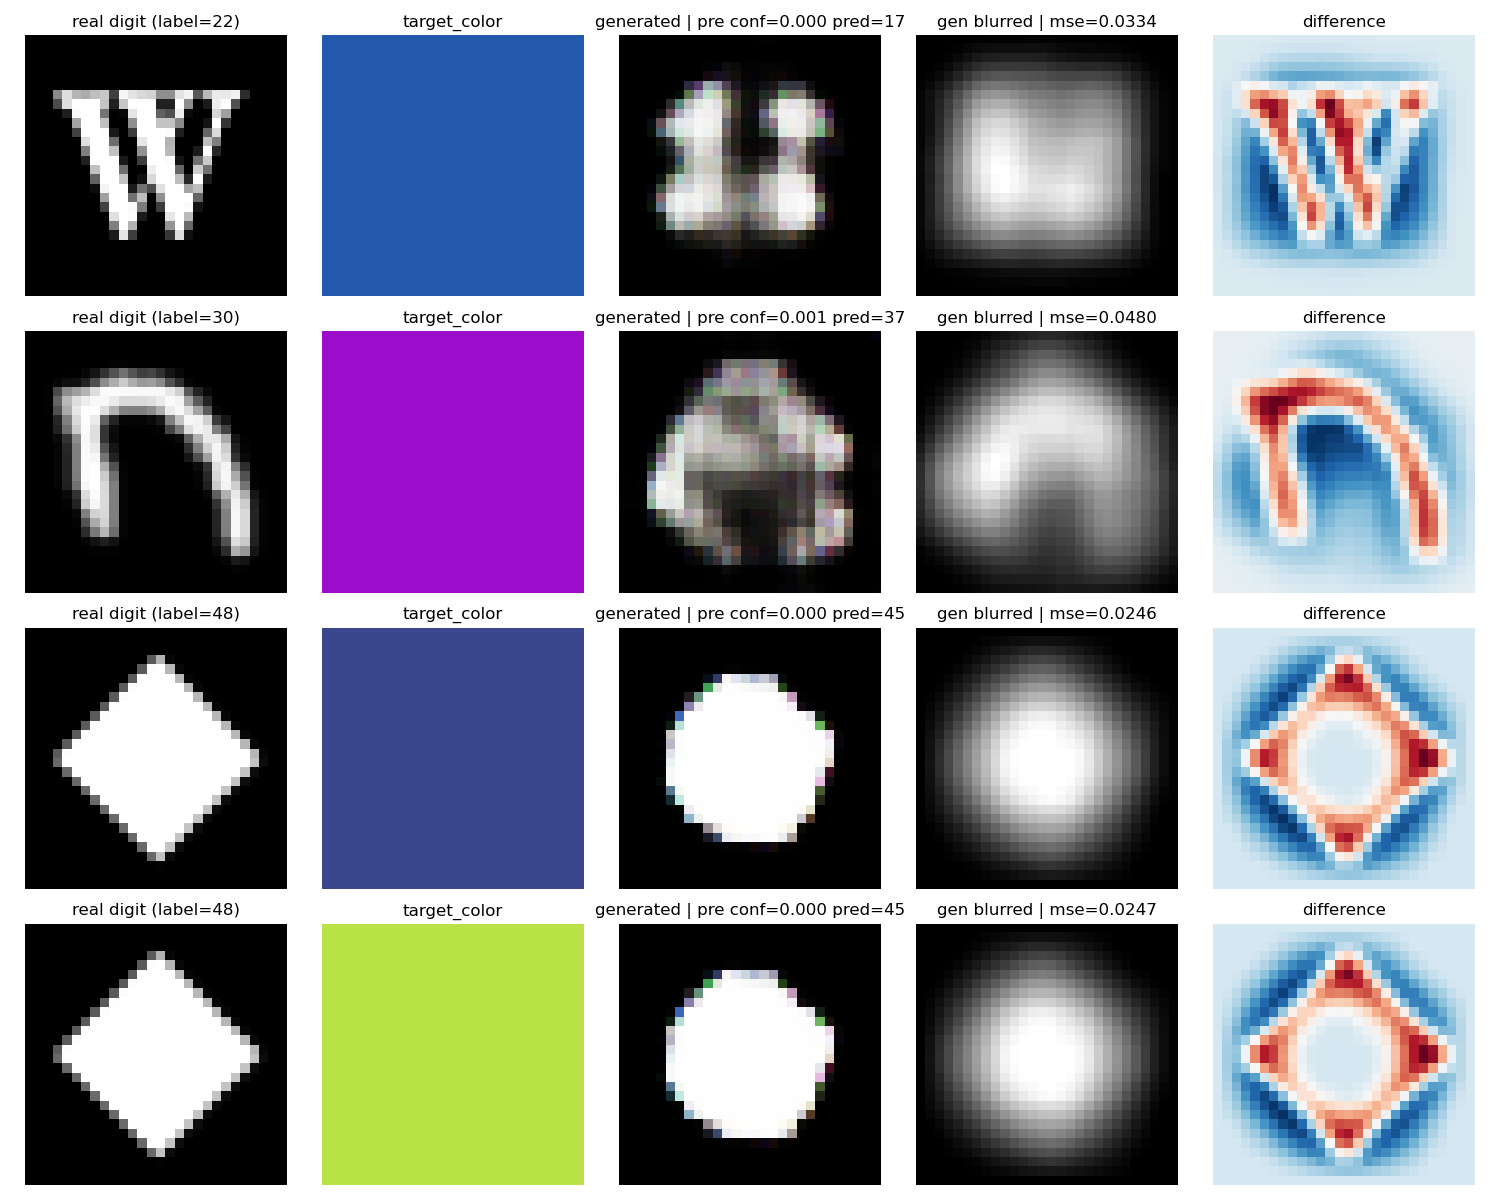

In [16]:
def show_generated(model, dataset, n=4, device=device):
    model.eval()
    fig, axes = plt.subplots(n, 5, figsize=(15, n*3))
    
    with torch.no_grad():
        for row in range(n):
            comp, label_int, target_color = dataset[random.randint(0, len(dataset)-1)]
            label  = torch.tensor([label_int]).to(device)
            i      = comp[3:].unsqueeze(0).to(device)  # real digit (1, 1, 28, 28)
            
            noise   = torch.randn(1, 2).to(device)
            onehot  = F.one_hot(label, num_classes=NUM_CLASSES).float()
            x       = torch.cat([onehot, noise], dim=1)
            
            generated    = model(x)
            generated_1d = generated.mean(dim=1, keepdim=True)
            logits   = ex_03_04a_model(generated_1d)
            probs    = F.softmax(logits, dim=1)
            conf_pre = probs[torch.arange(probs.shape[0]), label].item()
            pred_pre = logits.argmax(dim=1).item()

            blurred_gen  = box_blur(generated_1d)
            blurred_real = box_blur(i, kernel_size=3) #no-op
            post_loss    = F.mse_loss(blurred_gen, blurred_real).item()
            
            # conf_pre, pred_pre = m_classify_3d_with_conf(generated, label)

            axes[row, 0].imshow(i.squeeze().cpu(), cmap="gray")
            axes[row, 0].set_title(f"real digit (label={label_int})")
            color_patch = target_color.cpu().numpy()
            axes[row, 1].imshow([[color_patch]])
            axes[row, 1].set_title("target_color")
            axes[row, 2].imshow(generated.squeeze(0).cpu().permute(1,2,0))
            axes[row, 2].set_title(f"generated | pre conf={conf_pre:.3f} pred={pred_pre}")
            axes[row, 3].imshow(blurred_gen.squeeze().cpu(), cmap="gray")
            axes[row, 3].set_title(f"gen blurred | mse={post_loss:.4f}")
            axes[row, 4].imshow((blurred_gen - blurred_real).squeeze().cpu(), cmap="RdBu")
            axes[row, 4].set_title("difference")
            for ax in axes[row]: ax.axis("off")
    
    plt.tight_layout()
    plt.savefig("Results/EX04_generated.png")
    plt.close()
    
    from IPython.display import Image as IPImage, display
    display(IPImage("Results/EX04_generated.png"))

show_generated(ex_03_04b_model, train_set)

# culling the glyphs

In [32]:
@torch.no_grad()
def diagnose_glyph_recoverability(generator, dataset, num_classes,
                                   samples_per_class=50, noise_dim=2,
                                   blur_kernel_size=3, device="cuda"):
    """
    For each class:
      - Generate samples_per_class public images from the painter
      - Apply blur to both generated and real glyph
      - Compute size-normalized MSE between blurred generated and blurred real
    Returns per-class (mse, n) for ranking.
    """
    generator.eval().to(device)

    # Group dataset indices by class for sampling real glyphs
    class_to_indices = defaultdict(list)
    for idx in range(len(dataset)):
        _, lbl, _ = dataset[idx]
        class_to_indices[int(lbl)].append(idx)
        if all(len(v) >= samples_per_class for v in class_to_indices.values()) \
           and len(class_to_indices) == num_classes:
            break

    results = []
    for c in range(num_classes):
        if c not in class_to_indices or len(class_to_indices[c]) == 0:
            results.append((c, float("nan"), 0))
            continue

        idxs = class_to_indices[c][:samples_per_class]
        comps = torch.stack([dataset[i][0] for i in idxs]).to(device)
        real_glyphs = comps[:, 3:4]
        n = real_glyphs.shape[0]

        labels = torch.full((n,), c, dtype=torch.long, device=device)
        noise  = torch.randn(n, noise_dim, device=device)
        onehot = F.one_hot(labels, num_classes=num_classes).float()
        x      = torch.cat([onehot, noise], dim=1)
        gen    = generator(x)
        gen_1d = gen.mean(dim=1, keepdim=True)

        blurred_gen  = box_blur(gen_1d,      kernel_size=blur_kernel_size)
        blurred_real = box_blur(real_glyphs, kernel_size=blur_kernel_size)

        # Size-normalized MSE: divide each sample's MSE by its real glyph's
        # pixel mass, then rescale by mean mass so numbers stay interpretable.
        mse_per_sample = F.mse_loss(blurred_gen, blurred_real, reduction="none").mean(dim=[1,2,3])
        glyph_size     = real_glyphs.sum(dim=[1,2,3]).clamp(min=1.0)
        mse_normalized = mse_per_sample / glyph_size * glyph_size.mean()

        results.append((c, mse_normalized.mean().item(), n))

    return results


# ============================================================
results = diagnose_glyph_recoverability(
    generator=ex_03_04b_model,
    dataset=ex03_04_trainset,
    num_classes=NUM_CLASSES,
    samples_per_class=50,
)

print(f"{'class':<14} {'mse_norm':>9} {'n':>4}")
print("-" * 30)
for c, mse, n in sorted(results, key=lambda r: r[1]):
    print(f"{label_to_str(c):<14} {mse:>9.4f} {n:>4}")

# Cull bottom 30% by normalized MSE
n_keep = int(NUM_CLASSES * 0.7)
sorted_by_mse = sorted(results, key=lambda r: r[1])  # ascending: best first
keep_set = set(c for c, _, _ in sorted_by_mse[:n_keep])
cull_set = set(c for c, _, _ in sorted_by_mse[n_keep:])

print(f"\nKeeping {len(keep_set)}, culling {len(cull_set)}:")
print("Culled:", sorted([label_to_str(c) for c in cull_set]))

class           mse_norm    n
------------------------------
t                 0.0679   50
4                 0.0690   50
1                 0.0735   50
h                 0.0740   50
0                 0.0756   50
A                 0.0769   50
6                 0.0785   50
T                 0.0792   50
8                 0.0816   50
5                 0.0818   50
7                 0.0826   50
2                 0.0830   50
Y                 0.0831   50
X                 0.0871   50
N                 0.0878   50
d                 0.0911   50
3                 0.0916   50
9                 0.0917   50
L                 0.0937   50
f                 0.0941   50
F                 0.0942   50
▼                 0.0949   50
a                 0.0950   50
★                 0.0966   50
R                 0.0979   50
E                 0.1013   50
K                 0.1023   50
♥                 0.1027   50
n                 0.1040   50
✚                 0.1051   50
V                 0.1069   50
M        

# Saving the Generations

In [34]:
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
from collections import defaultdict

@torch.no_grad()
def build_painter_priors(generator, num_classes, samples_per_class=20,
                         noise_dim=2, device="cuda"):
    """
    Generate (label, public_image) pairs from the EX_03_04b generator
    to use as priors for the painter network in EX_03_05.
    """
    generator.eval().to(device)

    all_imgs   = []
    all_labels = []

    for c in range(num_classes):
        labels = torch.full((samples_per_class,), c, dtype=torch.long, device=device)
        noise  = torch.randn(samples_per_class, noise_dim, device=device)
        onehot = F.one_hot(labels, num_classes=num_classes).float()
        x      = torch.cat([onehot, noise], dim=1)
        gen    = generator(x)  # (samples_per_class, 3, 28, 28)

        all_imgs.append(gen.cpu())
        all_labels.append(labels.cpu())

    imgs   = torch.cat(all_imgs, dim=0)    # (N*samples_per_class, 3, 28, 28)
    labels = torch.cat(all_labels, dim=0)  # (N*samples_per_class,)
    return imgs, labels


class PainterPriorDataset(Dataset):
    """
    For each __getitem__: pick a class uniformly, return (label, prior_image).
    Prior image is sampled with replacement from the K renders for that class.
    """
    def __init__(self, prior_imgs, prior_labels, num_classes):
        self.num_classes = num_classes
        self.imgs_by_class = defaultdict(list)
        for img, lbl in zip(prior_imgs, prior_labels):
            self.imgs_by_class[int(lbl)].append(img)
        # convert lists to stacked tensors for fast indexing
        self.imgs_by_class = {k: torch.stack(v) for k, v in self.imgs_by_class.items()}

    def __len__(self):
        # arbitrary; sampling is uniform over classes anyway
        return self.num_classes * 1000

    def __getitem__(self, idx):
        c = idx % self.num_classes  # cycle through classes for balance
        bank = self.imgs_by_class[c]
        i = torch.randint(0, bank.shape[0], (1,)).item()
        return bank[i], c


# ============================================================
# Build the prior bank
prior_imgs, prior_labels = build_painter_priors(
    generator=ex_03_04b_model,
    num_classes=NUM_CLASSES,
    samples_per_class=20,
    noise_dim=2,
)

ex03_05_priors = PainterPriorDataset(prior_imgs, prior_labels, NUM_CLASSES)
ex03_05_priorloader = DataLoader(ex03_05_priors, batch_size=config.batch_size, shuffle=True)

torch.save({"imgs": prior_imgs, "labels": prior_labels},
           "Results/ex03_05_prior_bank.pt")

print(f"Built prior bank: {len(prior_imgs)} images across {NUM_CLASSES} classes")
print(f"  ({20} samples × {NUM_CLASSES} classes)")

Built prior bank: 1100 images across 55 classes
  (20 samples × 55 classes)
